# Chemical Similarity
In this lab, we focus on generating fingerprints and evaluating the Tanimoto similarity.

We will also do some visualization.

New python package:
- `seaborn`: similar to matplotlib, popular among young people.
- `numpy`: a very fundamental python library to handle matrices.

In [33]:
!pip -q install rdkit

In [34]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem

## Generating the MACCS fingerprint given a SMILES

Function used
`rdkit.AllChem.GetMACCSKeysFingerprint(mol)`




In [35]:
smiles = "CCO"
mol = Chem.MolFromSmiles(smiles)
fp = AllChem.GetMACCSKeysFingerprint(mol)
print("Raw fingerprint:", fp) # an rdkit data structure
print("The bit string of the fingerprint: ")
print(fp.ToBitString()) # explicitly print the bit string.

Raw fingerprint: <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x7b0d900c53f0>
The bit string of the fingerprint: 
00000000000000000000000000000000000000000000000000000000000000000000000000000000001000000000000000000000000001000010000000000000000000000001000000000000010101001000100


### Let's apply this to more molecules

In [36]:
# Define a dictionary of SMILES
smiles = {
    "ethanol": "CCO",
    "propanol": "CCCO",
    "acetone": "CC(=O)C",
    "acetic_acid": "CC(=O)O",
    "ethyl_acetate": "CCOC(=O)C",
    "benzene": "c1ccccc1"
}
# construct the rdkit molecular objects for each SMILES
mols = {} # empty dictionary
for name, smi in smiles.items():
    mols[name] = Chem.MolFromSmiles(smi)
# you can use the following one line for the same thing:
# mols = {name: Chem.MolFromSmiles(smi) for name, smi in smiles.items()}


In [37]:
# Evaluate the MACCS fingerprints for each molecule
fps_maccs = {}
for name, mol in mols.items():
    fps_maccs[name] = AllChem.GetMACCSKeysFingerprint(mol)
# one line alternative
# fps_maccs = {name: AllChem.GetMACCSKeysFingerprint(mol) for name, mol in mols.items()}

## Use Tanimoto metric to determine similarities
The function used:

`rdkit.DataStructs.TanimotoSimilarity()`, and the inputs are two fingerprints.

In [38]:
# define a function to wrap the long function name.
def tanimoto(a, b):
    return DataStructs.TanimotoSimilarity(a, b)
m_name1 = "ethanol"
m_name2 = "propanol"
print(f"The Tanimoto similarity between {m_name1} and {m_name2} is: ")
print(tanimoto(fps_maccs[m_name1], fps_maccs[m_name2]))

The Tanimoto similarity between ethanol and propanol is: 
0.6428571428571429


In [39]:
# Now let's evaluate all of it:
for m1 in fps_maccs:
    for m2 in fps_maccs:
        print(f"{m1:12s} vs {m2:12s}: {tanimoto(fps_maccs[m1], fps_maccs[m2]):.2f}")
    print()

ethanol      vs ethanol     : 1.00
ethanol      vs propanol    : 0.64
ethanol      vs acetone     : 0.15
ethanol      vs acetic_acid : 0.33
ethanol      vs ethyl_acetate: 0.47
ethanol      vs benzene     : 0.00

propanol     vs ethanol     : 0.64
propanol     vs propanol    : 1.00
propanol     vs acetone     : 0.11
propanol     vs acetic_acid : 0.24
propanol     vs ethyl_acetate: 0.35
propanol     vs benzene     : 0.00

acetone      vs ethanol     : 0.15
acetone      vs propanol    : 0.11
acetone      vs acetone     : 1.00
acetone      vs acetic_acid : 0.30
acetone      vs ethyl_acetate: 0.27
acetone      vs benzene     : 0.00

acetic_acid  vs ethanol     : 0.33
acetic_acid  vs propanol    : 0.24
acetic_acid  vs acetone     : 0.30
acetic_acid  vs acetic_acid : 1.00
acetic_acid  vs ethyl_acetate: 0.43
acetic_acid  vs benzene     : 0.00

ethyl_acetate vs ethanol     : 0.47
ethyl_acetate vs propanol    : 0.35
ethyl_acetate vs acetone     : 0.27
ethyl_acetate vs acetic_acid : 0.43
ethyl_ac

### We could use a heat map to visualize the above result
We put them into a matrix T, where T[i, j] is the Tanimoto similarity between the ith and jth molecule.
This will use `numpy` array.

We will use `matplotlib` to visualize the array.

You can also explore using `seaborn` for the plotting tasks.

In [12]:
import numpy as np # the most important package to deal with matrices (arrays)

In [40]:
Tmat = np.zeros((len(fps_maccs), len(fps_maccs))) # define an zero valued array (matrix)
i = 0
for m1 in fps_maccs:
    j = 0
    for m2 in fps_maccs:
        Tmat[i, j] = tanimoto(fps_maccs[m1], fps_maccs[m2])
        j += 1
    i += 1
print(Tmat)

[[1.         0.64285714 0.15384615 0.33333333 0.46666667 0.        ]
 [0.64285714 1.         0.11111111 0.23529412 0.35       0.        ]
 [0.15384615 0.11111111 1.         0.3        0.26666667 0.        ]
 [0.33333333 0.23529412 0.3        1.         0.42857143 0.        ]
 [0.46666667 0.35       0.26666667 0.42857143 1.         0.        ]
 [0.         0.         0.         0.         0.         1.        ]]


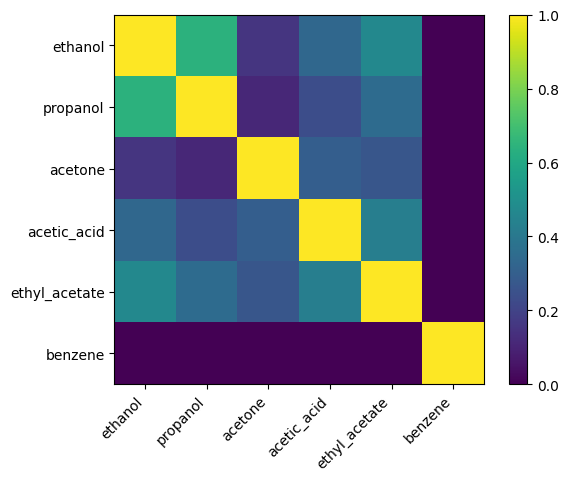

In [41]:
# we used matplotlib in the previous lectures
# You could look up how to make your plots prettier, e.g., change the color scheme.
from matplotlib import pyplot as plt

fig, ax = plt.subplots()
im = ax.imshow(Tmat)
plt.colorbar(im, ax=ax)
# add labels
names = list(fps_maccs.keys())
ax.set_xticks(range(len(names)))
ax.set_yticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticklabels(names)
plt.show()

<Axes: >

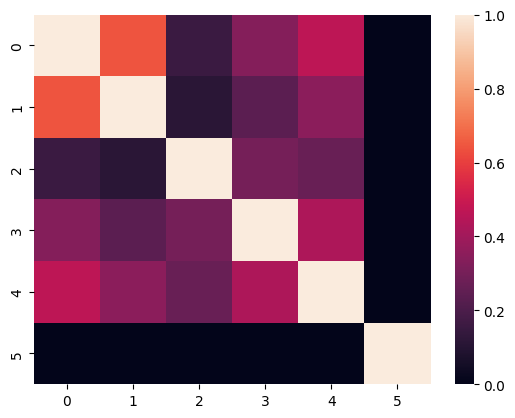

In [42]:
# # # seaborn is also a popular plotting package, with some more features sometimes.
import seaborn as sns
sns.heatmap(Tmat)

## Morgan (ECFP) similarity
Let's explore another type of fingerprints.

In [43]:
# # the following is not working well...
# mfpgen = Chem.rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=2048)
# def get_morgan(mol):
#     mfpgen.GetFingerprint(mol)

In [44]:
fps_morgan = {
    name: AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    for name, mol in mols.items()
}

[23:56:06] DEPRECATION WARNING: please use MorganGenerator
[23:56:06] DEPRECATION WARNING: please use MorganGenerator
[23:56:06] DEPRECATION WARNING: please use MorganGenerator
[23:56:06] DEPRECATION WARNING: please use MorganGenerator
[23:56:06] DEPRECATION WARNING: please use MorganGenerator
[23:56:06] DEPRECATION WARNING: please use MorganGenerator


In [45]:
for m1 in fps_morgan:
    for m2 in fps_morgan:
        print(f"{m1:12s} vs {m2:12s}: {tanimoto(fps_morgan[m1], fps_morgan[m2]):.2f}")
    print()


ethanol      vs ethanol     : 1.00
ethanol      vs propanol    : 0.56
ethanol      vs acetone     : 0.20
ethanol      vs acetic_acid : 0.18
ethanol      vs ethyl_acetate: 0.25
ethanol      vs benzene     : 0.00

propanol     vs ethanol     : 0.56
propanol     vs propanol    : 1.00
propanol     vs acetone     : 0.17
propanol     vs acetic_acid : 0.15
propanol     vs ethyl_acetate: 0.22
propanol     vs benzene     : 0.00

acetone      vs ethanol     : 0.20
acetone      vs propanol    : 0.17
acetone      vs acetone     : 1.00
acetone      vs acetic_acid : 0.62
acetone      vs ethyl_acetate: 0.33
acetone      vs benzene     : 0.00

acetic_acid  vs ethanol     : 0.18
acetic_acid  vs propanol    : 0.15
acetic_acid  vs acetone     : 0.62
acetic_acid  vs acetic_acid : 1.00
acetic_acid  vs ethyl_acetate: 0.31
acetic_acid  vs benzene     : 0.11

ethyl_acetate vs ethanol     : 0.25
ethyl_acetate vs propanol    : 0.22
ethyl_acetate vs acetone     : 0.33
ethyl_acetate vs acetic_acid : 0.31
ethyl_ac

You can do the same visualization!